# Parameters

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterHDBSCANModule as cluster
import Modules.FutureAnalysisModule as fa
from Modules.config import CONFIG

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = CONFIG["datapath"]
COVID_TRAIN_DATA_FILE = CONFIG["covid_train_data_file"]
COVID_TEST_DATA_FILE = CONFIG["covid_test_data_file"]
FUTURE_DATA_FILE = CONFIG["future_data_file"]

CONTROL_GROUP_TRAIN = CONFIG["control_group_train"]
CONTROL_GROUP_TEST = CONFIG["control_group_test"]
CONTROL_GROUP_READMISSION = CONFIG["control_group_readmission"]

FIGSIZE_CLUSTER_HEATMAP = CONFIG["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = CONFIG["figsize_future_heatmap"]
IMAGES_SAVE_PATH = CONFIG["image_save_path"]
TRIALS_OPTUNA = 250

# Import data

In [2]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

control_train = pd.read_csv(data_folder / CONTROL_GROUP_TRAIN)
control_test = pd.read_csv(data_folder / CONTROL_GROUP_TEST)
control = pd.concat([control_train, control_test], axis=0)
control_readmission = pd.read_csv(data_folder / CONTROL_GROUP_READMISSION)

# Feature engineering: morte após a internação
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [3]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

# Mice Data

In [4]:
categorical_features = [
            "myocardial_infarct",
            "congestive_heart_failure",
            "peripheral_vascular_disease",
            "cerebrovascular_disease",
            "dementia",
            "chronic_pulmonary_disease",
            "rheumatic_disease",
            "peptic_ulcer_disease",
            "mild_liver_disease",
            "diabetes_without_cc",
            "diabetes_with_cc",
            "paraplegia",
            "renal_disease",
            "malignant_cancer",
            "severe_liver_disease",
            "metastatic_solid_tumor",
            "aids",
            "gender_M",
            "died_in_stay",
            "died_after",
            "died",
            "COVID"
        ]

In [5]:
features_not_considered = ['died', 'died_in_stay', 'died_after', 'COVID', 'subject_id', 'hadm_id']

In [6]:
helper = cluster.HDBSCANClusterHelper(data=data_covid, features_not_considered=features_not_considered)

2026-02-25 00:13:48,354 - ClusterBaseModule - INFO - ClusterBaseHelper initialized: 3355 records, 67 features (22 categorical, 51 numerical)
2026-02-25 00:13:48,354 - Modules.ClusterHDBSCANModule - INFO - HDBSCANClusterHelper initialized: 3355 records, scaler='standard'


## Find best hyperparameters for DBSCAN - cluster_selection_method: 'eom'

In [7]:
param = {
    "min_cluster_size": {"min": 2, "max": 30},
    "min_samples": {"min": 1, "max": 20}
}

### DBCV

In [8]:
# os.environ["PYTHONWARNINGS"] = "ignore"
# dbcv_df, dbcv_param, dbcv_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="dbcv",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=85
# )

In [9]:
dbcv_param = {'min_cluster_size': 2, 'min_samples': 5}

### DISCO

In [10]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# disco_df, disco_param, disco_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="disco",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=85
# )

In [11]:
disco_param = {'min_cluster_size': 2, 'min_samples': 3}

### DSI

In [12]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# dsi_df, dsi_param, dsi_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="dsi",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=85
# )

In [13]:
dsi_param = {'min_cluster_size': 10, 'min_samples': 1}

### Silhouette

In [14]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# silhouette_df, silhouette_param, silhouette_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="silhouette",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=85
# )

In [15]:
silhouette_param = {'min_cluster_size': 2, 'min_samples': 4}

### Metrics

In [16]:
helper.clustering(min_cluster_size=dbcv_param['min_cluster_size'], min_samples=dbcv_param['min_samples'])
helper.get_metrics()

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-02-25 00:13:49,047 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 3 clusters
2026-02-25 00:13:49,048 - Modules.ClusterHDBSCANModule - INFO - HDBSCAN clustering complete: min_cluster_size=2, min_samples=5, clusters=2, noise_points=524
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core

{'silhouette': 0.435,
 'dbcv': 0.8438147428446567,
 'dsi': np.float64(0.341),
 'disco': np.float64(0.3851592825648012)}

In [17]:
helper.clustering(min_cluster_size=disco_param['min_cluster_size'], min_samples=disco_param['min_samples'])
helper.get_metrics()

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-02-25 00:13:55,141 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 5 clusters
2026-02-25 00:13:55,141 - Modules.ClusterHDBSCANModule - INFO - HDBSCAN clustering complete: min_cluster_size=2, min_samples=3, clusters=4, noise_points=715
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core

{'silhouette': -0.157,
 'dbcv': 0.7868844611655837,
 'dsi': np.float64(0.508),
 'disco': np.float64(-0.19437786561287737)}

In [18]:
helper.clustering(min_cluster_size=dsi_param['min_cluster_size'], min_samples=dsi_param['min_samples'])
helper.get_metrics()

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-02-25 00:14:00,898 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 3 clusters
2026-02-25 00:14:00,898 - Modules.ClusterHDBSCANModule - INFO - HDBSCAN clustering complete: min_cluster_size=10, min_samples=1, clusters=2, noise_points=2757
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/co

{'silhouette': -0.305,
 'dbcv': 0.1782412525293902,
 'dsi': np.float64(0.179),
 'disco': np.float64(-0.38740553383641657)}

In [19]:
helper.clustering(min_cluster_size=silhouette_param['min_cluster_size'], min_samples=silhouette_param['min_samples'])
helper.get_metrics()

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-02-25 00:14:05,559 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 3 clusters
2026-02-25 00:14:05,559 - Modules.ClusterHDBSCANModule - INFO - HDBSCAN clustering complete: min_cluster_size=2, min_samples=4, clusters=2, noise_points=537
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core

{'silhouette': 0.44,
 'dbcv': 0.8399399315640403,
 'dsi': np.float64(0.368),
 'disco': np.float64(0.42906275624009127)}

## Best Result -> DISCO

In [20]:
best_param = silhouette_param

In [21]:
helper.clustering(min_cluster_size=best_param['min_cluster_size'], min_samples=best_param['min_samples'])
helper.get_metrics()

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2026-02-25 00:14:11,241 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 3 clusters
2026-02-25 00:14:11,241 - Modules.ClusterHDBSCANModule - INFO - HDBSCAN clustering complete: min_cluster_size=2, min_samples=4, clusters=2, noise_points=537
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core

{'silhouette': 0.44,
 'dbcv': 0.8399399315640403,
 'dsi': np.float64(0.368),
 'disco': np.float64(0.42906275624009127)}

/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/ClusterBaseModule.py:476: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_stats = self._clustered_data.groupby("Cluster").apply(calculate_stats).T
2026-02-25 00:14:16,259 - ClusterBaseModule - INFO - Calculated categorical stats for 3 clusters
/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/ClusterBaseModule.py:1451: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.38 x' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot_labels.loc[idx] = df.loc[idx].map(lambda x: f"{x:.2f} x")
/Users/gabrielleite/Bac

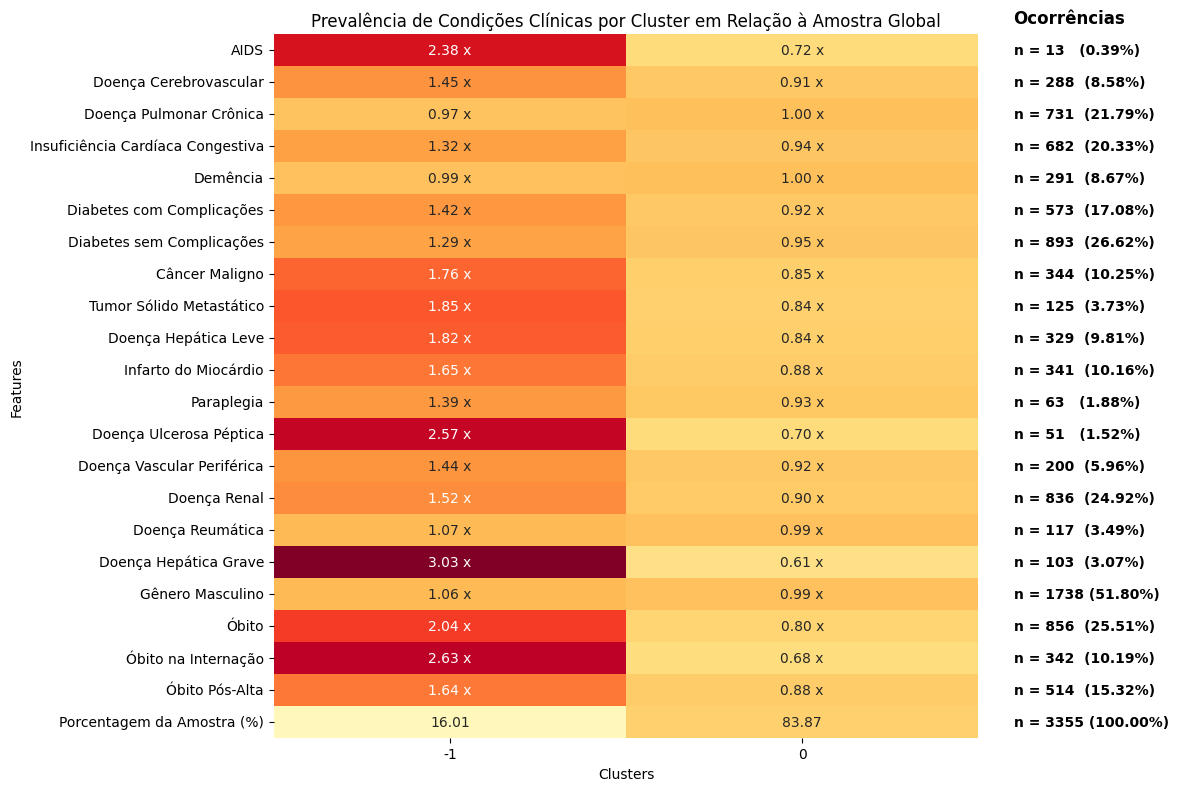

2026-02-25 00:14:16,465 - ClusterBaseModule - INFO - Created categorical heatmap: 22 features, 2 clusters


In [22]:
helper.heatmap_clusters_categorical(
    figsize=FIGSIZE_CLUSTER_HEATMAP,
    relative_total=True,
    # savepath=IMAGES_SAVE_PATH + "hdbscan-all-categorical-relative",
)

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/v

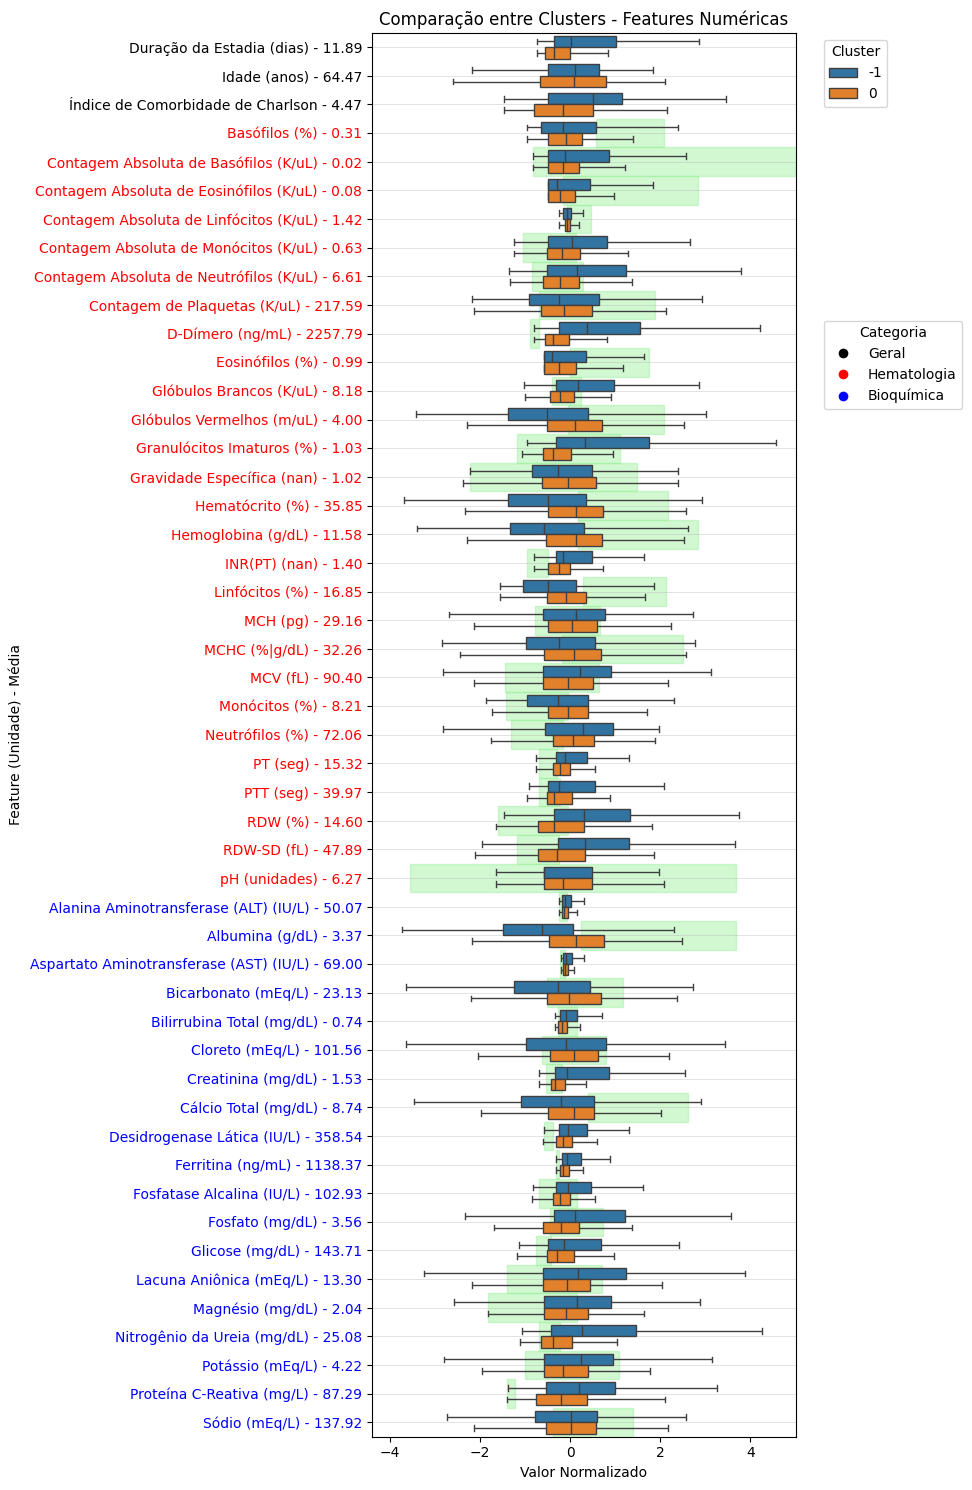

2026-02-25 00:14:17,025 - ClusterBaseModule - INFO - Displayed numerical comparison: 49 features, 2 clusters


[]

In [23]:
helper.show_cluster_compare_numerical(
    figsize=(10, 15),
    # savepath=IMAGES_SAVE_PATH + "hdbscan-all-numerical",
)

In [24]:
selected_clusters = [-1, 0]

In [25]:
helper.set_clustered_autoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:23<00:00,  4.20it/s]


2026-02-25 00:14:41,150 - ClusterBaseModule - INFO - Autoencoder clustering completed: 3355 records, embedding_size=2


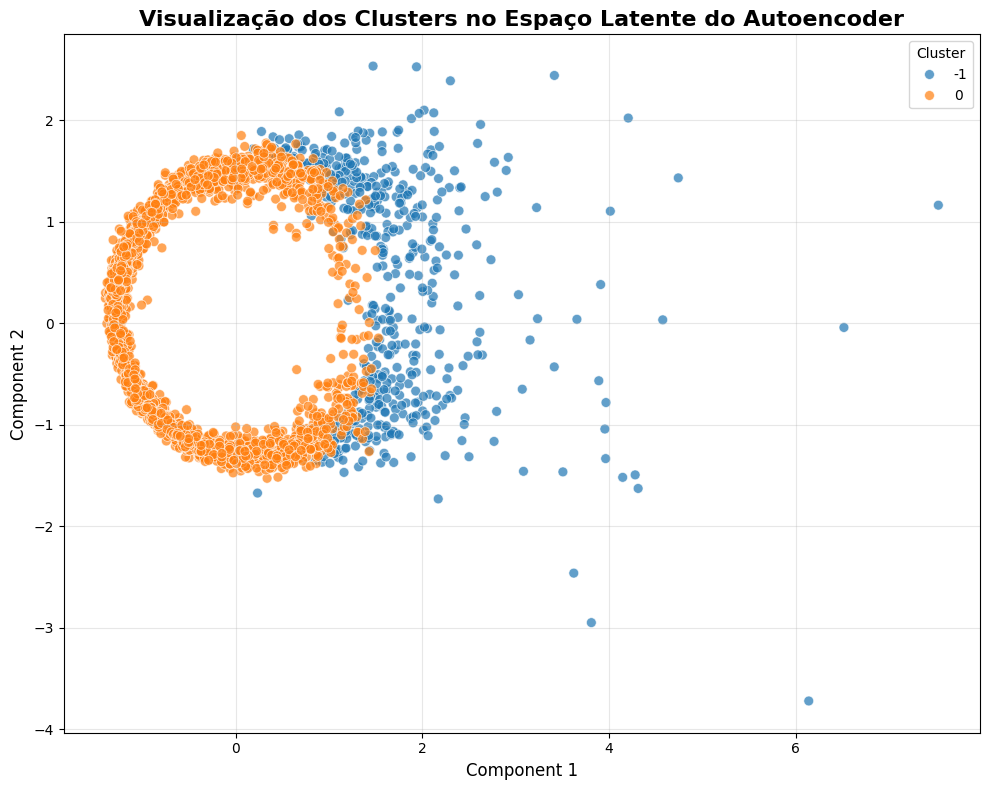

2026-02-25 00:14:41,270 - ClusterBaseModule - INFO - Displayed autoencoder clusters: 2 clusters


In [26]:
helper.show_clustered_autoencoder(
    selected_clusters=selected_clusters,
    seperate_clusters=False
    # savepath=IMAGES_SAVE_PATH + "hdbscan-all-autoencoder",
)

##### Future data


2026-01-29 16:20:18,855 - Modules.FutureAnalysisModule - WARNING - 84 subject_ids in target data are missing from reference data. These will be filtered out.
2026-01-29 16:20:18,860 - Modules.FutureAnalysisModule - WARNING - 551 subject_ids in target data are missing from reference data. These will be filtered out.
2026-01-29 16:20:18,875 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 3649 records
2026-01-29 16:20:18,886 - Modules.FutureAnalysisModule - INFO - Auto-detected 19 binary features for analysis
2026-01-29 16:20:18,912 - Modules.FutureAnalysisModule - INFO - Delta clusters calculated for 1 clusters
2026-01-29 16:20:18,914 - Modules.FutureAnalysisModule - INFO - FutureAnalysisHelper initialized with 3355 past records and 2257 future records
2026-01-29 16:20:18,918 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 976 records
2026-01-29 16:20:18,923 - Modules.FutureAnalysisModule - INFO - Auto-detected 20 binary features for analysis
2026-01-29 16:20:

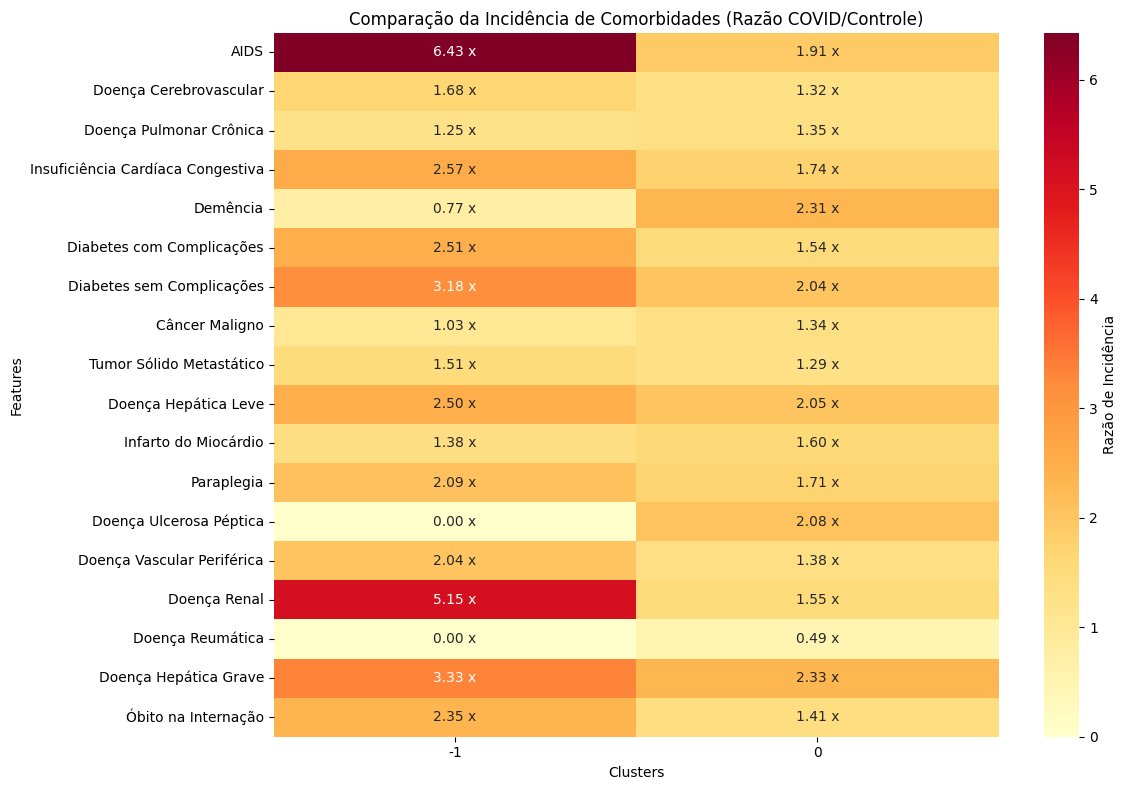

In [ ]:
future_helper = fa.FutureAnalysisHelper(
    helper.clustered_data, future_data, control, control_readmission
)
delta = future_helper.get_delta_clusters(percentage=True, relative_total=True)
future_helper.show_delta_heatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    relative_total=True,
    selected_clusters=selected_clusters,
    savepath=IMAGES_SAVE_PATH + "hdbscan-all-future",
)

In [ ]:
future_helper.get_mean_readmission()

2026-01-29 16:20:19,310 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 2257 records
2026-01-29 16:20:19,312 - Modules.FutureAnalysisModule - INFO - Calculated mean readmission for 2 clusters


{'Mean readmission Cluster -1': np.float64(2.61),
 'Mean readmission Cluster 0': np.float64(2.26),
 'Overall Mean readmission': 2.31}

In [ ]:
future_helper.get_mean_days_gap()

2026-01-29 16:20:19,322 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 976 records
2026-01-29 16:20:19,324 - Modules.FutureAnalysisModule - INFO - Calculated mean days gap for 2 clusters


{'Mean days gap Cluster -1': np.float64(112.96),
 'Mean days gap Cluster 0': np.float64(130.23),
 'Overall Mean days gap': 127.49}

In [ ]:
future_helper.get_mortality_rates(only_first_admission=True)

2026-01-29 16:20:19,333 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 976 records
2026-01-29 16:20:19,338 - Modules.FutureAnalysisModule - INFO - Calculated mortality rates for 2 clusters


{'Mortality rate Cluster -1': 0.04,
 'Mortality rate Cluster 0': 0.12,
 'Overall Mortality rate': 0.09}

### Add Log

In [ ]:
# log_file = "../log.csv"
# current_dir = os.getcwd()
# log_file_path = os.path.join(current_dir, log_file)

# metrics = helper.getMetrics()

# # Add line to save log
# if os.path.exists(log_file_path):
#     with open(log_file_path, 'a') as f:
#         f.write(f"HDBSCAN, None, Comprehensive, {metrics['disco']}, {metrics['dbcv']}, {metrics['dsi']}, {metrics['silhouette']}\n")